## Building PDF Query Chatbot with Images , texts and tables

In [ ]:
# %pip install -Uq "unstructured[all-docs]" pillow lxml pillow

Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'antlr4-python3-runtime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'antlr4-python3-runtime'. Discussion can be found at https://github.com/pypa/pip/issues/6334
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
crewai 1.4.1 requires chromadb~=1.1.0, but you have chromadb 1.3.5 which is incompatible.
gradio 5.49.1 requires aiofiles<25.0,>=22.0, but you have aiofiles 25.1.0 which is incompatible.
gradio 5.49.1 requires pillow<12.0,>=8.0, but you have pillow 12.0.0 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have p

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
crewai 1.4.1 requires chromadb~=1.1.0, but you have chromadb 1.3.6 which is incompatible.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [22]:
from dotenv import load_dotenv
load_dotenv()
import os

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"

## Data Pipelining or Extraction

In [1]:
from unstructured.partition.pdf import partition_pdf

output_path="./content/chunks"
file_path=r"C:\Users\dewan\Coding\MLOps\IAI_Solutions\content\qatar_test_doc.pdf"

chunks=partition_pdf(
    filename=file_path,
    infer_table_structure=True,      # Extract tables
    strategy="hi_res",               # Mandatory to infer tables

    extract_image_block_types=["Image", "Table"],
    # image_output_dir_path=output_path,

    extract_image_block_to_payload=True,

    chunking_strategy="by_title",
    max_characters=10000,
    combine_text_under_n_chars=2000,
    new_after_n_chars=6000,

)


c:\ProgramData\anaconda3\envs\FreeGenAI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Cannot set gray non-stroke color because /'P0' is an invalid float value
Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P0' is an invalid float value
Cannot set gray non-stroke color because /'P1' is an invalid float value
Cannot set gray non-stroke color because /'P0' is an invalid float value


The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


## Saving and loading data in JSON format to save time

In [2]:
import json
from unstructured.staging.base import dict_to_elements, elements_to_dicts

# Convert elements to dictionaries
chunks_dict = elements_to_dicts(chunks)

# Save to JSON
with open("chunks.json", "w", encoding="utf-8") as f:
    json.dump(chunks_dict, f, ensure_ascii=False, indent=2)


In [4]:
import json
from unstructured.staging.base import dict_to_elements

# Load JSON
with open("chunks.json", "r", encoding="utf-8") as f:
    chunks_dict = json.load(f)

# Convert back to elements
chunks = dict_to_elements(chunks_dict)


In [ ]:
# !pip install hf_xet

   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------- ----------------------------- 0.8/2.9 MB 5.6 MB/s eta 0:00:01
   ------------------------- -------------- 1.8/2.9 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 5.5 MB/s  0:00:00


In [5]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in loaded_chunks])

NameError: name 'loaded_chunks' is not defined

In [6]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [9]:
for c in chunks:
    print(type(c), c.text[:1000])

<class 'unstructured.documents.elements.CompositeElement'> ee

February 2025

INTERNATIONAL MONETARY FUND

IMF Country Report No. 25/47

QATAR

2124 ARTICLE IV CONSULTATION—PRESS RELEASE; STAFF REPORT; AND STATEMENT BY THE EXECUTIVE DIRECTOR FOR QATAR

Under Article IV of the IMF's Articles of Agreement, the IMF holds bilateral discussions with members, usually every year. In the context of the 2024 Article IV consultation with Qatar, the following documents have been released and are included in this package:

e A Press Release summarizing the views of the Executive Board as expressed during its January 27, 2025, consideration of the staff report that concluded the Article IV consultation with Qatar.

e The Staff Report prepared by a staff team of the IMF for the Executive Board's consideration on January 27, 2025, following discussions that ended on November 21, 2024, with the officials of Qatar on economic developments and policies. Based on information available at the time of thes

In [10]:
# Each CompositeElement containes a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

chunks[2].metadata.orig_elements

In [11]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True

elements = chunks[0].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': 'b8e82e60-790a-4a01-9257-d517bbe8a9ca',
 'text': '',
 'metadata': {'coordinates': {'points': ((144.4, 39.8),
    (144.4, 211.3),
    (304.0, 211.3),
    (304.0, 39.8)),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'detection_class_prob': 0.66723,
  'filetype': 'PPM',
  'image_base64': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCACrAKADASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLR

## Separate extracted elements into tables, text, and images

In [12]:
# separate tables from texts
tables = []
texts = []
# images = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)
        
    # if "Image" in str(type(chunk)):
    #     images.append(chunk)

In [13]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

In [14]:
from unstructured.documents.elements import Table, CompositeElement

def get_tables(chunks):
    tables = []
    for chunk in chunks:
        if isinstance(chunk, CompositeElement):
            for el in chunk.metadata.orig_elements:
                if isinstance(el, Table):
                    tables.append(el)
    return tables
tables = get_tables(chunks)

In [15]:
len(texts)

55

In [16]:
len(tables)

27

In [17]:
len(images)

100

In [18]:
images[1]

'/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCACjAKQDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwD3+iiigAooooAKKyPEWvw+HNLkvprW6uFRS223iLYxjlj0Uc9T79cV5vaeMj48s9YgvNWm0H7PbmWGO3kAV17l3K7jgkDAK5B6da3p4ec1zdDGpXjB8vU9frzjxb8ULnwtrkmmvoXmBQrLMbnAdT0IG3joe/as34M6ui2l3p1

## Checking images

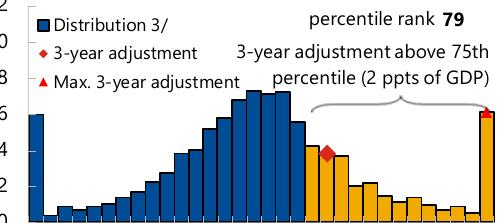

In [19]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[89])

## Summarizing

In [23]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

Prompt_text="""
Instructions:
1. You are a assistant tasked with summarizating tables and text.
2. Give a concise summary of the text or tables.
3. Respond only with the summary , no additional context.
4. Do not start your message by saying "Here is a summary" or anything like that.
5. Just give the summary as it is.

Table or text chunk: {element}
"""

prompt = ChatPromptTemplate.from_template(Prompt_text)

# Summary Chain
# model = ChatGroq(model="meta-llama/llama-4-maverick-17b-128e-instruct")
model = ChatGroq(model="llama-3.1-8b-instant")

summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()


In [ ]:
# Summarize text
# text_summaries = summarize_chain.batch(texts, {"max_concurrency": 1})

In [24]:
tables

In [25]:
# Summarize text
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 1})

# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html, {"max_concurrency": 1})

In [26]:
table_summaries

['Real GDP growth rate increased from 16% in 2021 to 42% in 2022, and is projected to reach 17% in 2024. Hydrocarbon production decreased by 3% in 2021 but increased to 14% in 2024. CPI inflation averaged 23% in 2021, 50% in 2022, and is projected to be 1% in 2024. Revenue increased from 296% of GDP in 2021 to 347% in 2022, and is projected to be 262% in 2024. The current account balance reached 268% of GDP in 2022, and is projected to be 15.5% in 2024.',
 'Fiscal policy should enhance resilience and diversification, while financial sector policy should maintain stability and deepen markets. Monetary policy should improve its operational framework and structural reforms should build a knowledge-based and sustainable economy.',
 'Estimating fiscal multipliers in Qatar and the Gulf Cooperation Council (GCC) countries.',
 'The table organizes macroeconomic developments into three sectors: Real, External, and Fiscal.',
 'This table provides financial data for Qatar from 2020-2029, includin

In [27]:
text_summaries

['The IMF concluded its 2024 Article IV consultation with Qatar, projecting 2% real GDP growth in 2024-25, driven by public investment, LNG expansion, and strong tourism. Medium-term growth is expected to accelerate to 4% on average. Headline inflation is projected to ease to 1% in 2024 and converge to 2% over the medium term.',
 "Executive Directors agreed with Qatar's resilient economy, commending its continued fiscal prudence and reform efforts. They recommended accelerating fiscal reforms, introducing a value-added tax, and improving financial stability. The Directors also supported Qatar's strategy to build a diversified, private sector-led economy and align domestic energy prices with export prices.",
 "Qatar's economy is expected to strengthen gradually, driven by LNG production expansion and reform gains, while fiscal and external surpluses will moderate. Reform momentum has increased, guided by the Third National Development Strategy, aiming for revenue diversification, spendi

## Image Summaries

In [28]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt_template = ChatPromptTemplate.from_messages([
    ("user", [
        {"type": "text", "text": """
Describe the image in detail.

Context: The image is part of the IMF 'QATAR 2024 ARTICLE IV CONSULTATION' documents.
"""},
        {"type": "image_url", "image_url": {"url": "{image_url}"}}
    ])
])

llm = ChatOpenAI(model="gpt-4o-mini")
parser = StrOutputParser()

def build_inputs(base64_images):
    formatted = []
    for img in base64_images:
        formatted.append(
            {"image_url": f"data:image/jpeg;base64,{img}"}
        )
    return formatted

# Prepare batch inputs
inputs = build_inputs(images)

# Run one by one (safer: avoids rate limit)
image_summaries = []
for inp in inputs:
    chain = prompt_template | llm | parser
    image_summaries.append(chain.invoke(inp))



In [42]:
len(image_summaries)

100

In [29]:
image_summaries

['The image features the logo of the International Monetary Fund (IMF). The logo is circular and predominantly blue. In the center, there are two globes that represent the world, depicted in white, showing outlines of continents. Surrounding the globes is the text “INTERNATIONAL MONETARY FUND” in a bold, white font, positioned above and below the globes. At the bottom of the logo, there’s a stylized depiction of a laurel branch, which typically symbolizes peace and prosperity. The entire design conveys a sense of global financial cooperation and stability.',
 'The image features the logo of the International Monetary Fund (IMF). The design consists of a circular emblem that incorporates two stylized representations of the Earth, with a focus on the continents. This globe is encircled by a band that reads "INTERNATIONAL MONETARY FUND" prominently at the top and bottom. \n\nThe color scheme is predominantly blue, which is often associated with trust, stability, and professionalism. The l

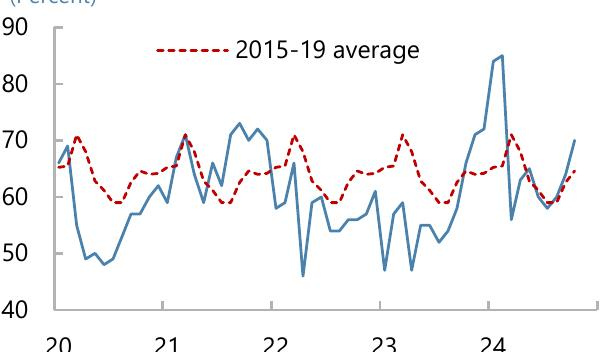

'The image depicts a line graph that represents data over a specified time period, likely related to economic indicators in Qatar, given the context of an IMF consultation. \n\n### Key Features:\n\n- **Axes**: \n  - The vertical axis represents a percentage scale, ranging from 40% to 90%.\n  - The horizontal axis represents the years, likely from 2020 to 2024, indicated by the numbers 20 to 24.\n\n- **Data Lines**:\n  - A solid blue line tracks the data values over the specified years. This line exhibits fluctuations, indicating varying percentages throughout the period.\n  - A dashed red line represents the average percentage for the years 2015-2019. This line provides a comparative baseline against the blue line.\n\n- **Trend Observations**:\n  - The blue line shows several peaks and troughs, suggesting volatility or significant changes in the measured metric.\n  - The red dashed line provides insight into whether the blue line is trending above or below historical averages.\n\n- **L

In [31]:
display_base64_image(images[8])
image_summaries[8]

## Load data summaries

In [1]:
from summaries import *

### Create a vector DB

In [23]:
import uuid
from langchain_chroma import Chroma
from langchain_core.stores import InMemoryStore  
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

# The vectorstore to use to index the child chunks
vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=OpenAIEmbeddings())

# The storage layer for the parent documents
store = InMemoryStore()
id_key = "doc_id"

# The retriever (empty to start)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
    persist_directory=r"C:\Users\dewan\Coding\MLOps\IAI_Solutions\chroma_IAI_db"    
)


In [25]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

embeddings = OpenAIEmbeddings()

embedding_dim = len(embeddings.embed_query("hello world"))
index = faiss.IndexFlatL2(embedding_dim)

vectorstore = FAISS(
    embedding_function=OpenAIEmbeddings(),
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

# The retriever (empty to start)
retriever2 = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
    persist_directory=r"C:\Users\dewan\Coding\MLOps\IAI_Solutions\FAISS_IAI_VS"    
)


In [26]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever2.vectorstore.add_documents(summary_texts)
retriever2.docstore.mset(list(zip(doc_ids, texts)))
print("Documents added:", retriever2.vectorstore.index.ntotal)


# Add tables
table_ids = [str(uuid.uuid4()) for _ in tables]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
]
retriever2.vectorstore.add_documents(summary_tables)
retriever2.docstore.mset(list(zip(table_ids, tables)))
print("Documents added:", retriever2.vectorstore.index.ntotal)


# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever2.vectorstore.add_documents(summary_img)
retriever2.docstore.mset(list(zip(img_ids, images)))
print("Documents added:", retriever2.vectorstore.index.ntotal)


Documents added: 55
Documents added: 82
Documents added: 182


In [ ]:
def clear_faiss(vs: FAISS):
    vs.index.reset()
    vs.docstore._dict.clear()
    vs.index_to_docstore_id.clear()
    print("FAISS vector store cleared.")

# clear_faiss(vector_store)

FAISS vector store cleared.


In [ ]:
# vectorstore.delete_collection()


AttributeError: 'FAISS' object has no attribute 'delete_collection'

In [ ]:
# Load the vectorstore
vectorstore = Chroma(
    collection_name="multi_modal_rag",
    embedding_function=OpenAIEmbeddings(),
    persist_directory=persist_dir
)

# Load the docstore
store = InMemoryStore()
if docstore_path.exists():
    with open(docstore_path, 'rb') as f:
        store.store = pickle.load(f)

# Recreate the retriever
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

In [28]:
# Retrieve
docs = retriever2.invoke(
    "Qatar’s Diversification Progress and Challenges"
)

In [29]:
docs

In [32]:
# Retrieve
docs = retriever2.invoke(
    "Qatar’s Diversification Progress and Challenges"
)

In [33]:
docs

In [34]:
for doc in docs:
    print(str(doc) + "\n\n" + "-" * 80)

30. Boosting Qatar’s economic complexity calls for (Text Figures 18 and 19):

e Fostering innovation. Qatar's patent applications rose rapidly over the last decade, more so than in its GCC peers. To promote innovation and support start-ups, a venture capital program ("Fund of Funds”) is being established by the QIA. NDS3 aims to increase Qatar's R&D funding from the current 0.7 percent of GDP to 1.5 percent, with the majority from the private sector. More attention is needed to enhance Qatar’s R&D spending efficiency and quality. Further improvement in intellectual property rights protection (e.g., in patent and trademark protection) is also key.

13 See Annex IX. “Promoting Gender Equality: Enhancing Women’s Workforce in Qatar” in the 2023 Staff Report for Qatar.

22 INTERNATIONAL MONETARY FUND

QATAR

e Promoting trade diversification. Progress in Qatar's export diversification is limited, mainly in services export (transportation and tourism). For a country with a small domestic mar

## RAG Pipelines

In [37]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from base64 import b64decode
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {"images": b64, "texts": text}


def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element.text

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{image}"},
                }
            )

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


chain = (
    {
        "context": retriever2 | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatOpenAI(model="gpt-4o-mini")
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever2 | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOpenAI(model="gpt-4o-mini")
        | StrOutputParser()
    )
)

### Errors

In [67]:

import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [8]:
import uuid
import pickle
from pathlib import Path
from langchain_chroma import Chroma
from langchain_core.stores import InMemoryStore  
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

persist_dir = r"C:\Users\dewan\Coding\MLOps\IAI_Solutions\saved_retriever\chroma_db\metadat.pkl"
docstore_path = Path(r"C:\Users\dewan\Coding\MLOps\IAI_Solutions\saved_retriever\chroma_db\docstore.pkl")
id_key = "id"

# Load the vectorstore
vectorstore = Chroma(
    collection_name="multi_modal_rag",
    embedding_function=OpenAIEmbeddings(),
    persist_directory=persist_dir
)

# Load the docstore
store = InMemoryStore()
if docstore_path.exists():
    with open(docstore_path, 'rb') as f:
        store.store = pickle.load(f)

# Recreate the retriever
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

In [38]:
response = chain.invoke(
    "What is the Recent economic developements"
)

print(response)

Recent economic developments in Qatar indicate a normalization of growth following the 2022 FIFA World Cup. However, non-hydrocarbon activity weakened in 2023 due to contractions in construction, trade, transportation, and real estate sectors. Real estate prices remained weak but have shown signs of recovery, while manufacturing production is also displaying signs of troughing. Population and employment growth are strong, contributing to domestic demand as labor force participation rates have recovered to pre-COVID levels.

Inflation has seen disinflation in non-tradables, while tradables inflation has been stable. The monetary policy has tightened in real terms, with the domestic policy deposit rate moving less than the US Fed Funds rate during cycles.

On the fiscal side, there has been a moderate fiscal loosening in 2023 amid slower growth, but the authorities plan to resume gradual fiscal consolidation in 2024 with projected spending cuts. The fiscal posture is expected to strength

Response: Real Non-hydro GDP Growth for the year 2023 is not explicitly mentioned in the provided context. However, based on trends shown in similar graphs or figures leading up to 2023, it can be inferred that non-hydrocarbon activity weakened during that year. If you have additional data or specific values from the context, I can help interpret them.


Context:
Figure 5. Qatar: Credit and Financial Sector Developments

Real private sector credit growth picked up since late 2023...

..While credit to the public sector remains the largest share of bank assets.

Bank Credit to Private Sector

(Percent, year on year)

Stock of Bank Domestic Credit by Borrower (Percent of total)

30 Real Nominal 20 10 12 #14 #16 #18 20 22 24

40 October 2024 e 30 e 2019 average 20 e 0 N ER efion x A) 2 £ ire] io) 2 iv) Real esta Consumption loans

Banks’ credit to non-hydro GDP gap is estimated to be negative in 2023.

Bank foreign liabilities remained elevated but moderating...

Credit to GDP Gap 1/

(Pe

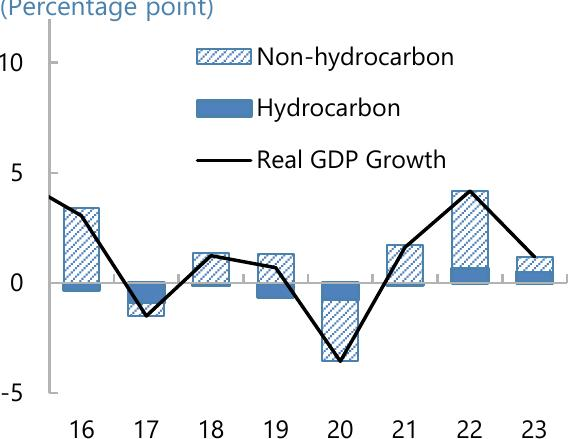

In [39]:
response = chain_with_sources.invoke(
    "What is Real Non-hydro GDP Growth?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text.text)
    print("Page number: ", text.metadata.page_number)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)